In [63]:
import pandas as pd

# load the data
df = pd.read_csv("../laptop_data_cleaned.csv")

# handle these better with your own dataset, here we are simply dropping these

df.head()

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [64]:
# Check value counts for Company before modifying ordinal categories
df['Company'].value_counts()

Company
Dell         291
Lenovo       289
HP           268
Asus         151
Acer         101
MSI           54
Toshiba       48
Apple         21
Samsung        8
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64

In [65]:
# Check value counts for TypeName before modifying ordinal categories
df['TypeName'].value_counts()

TypeName
Notebook              706
Gaming                205
Ultrabook             194
2 in 1 Convertible    116
Workstation            29
Netbook                23
Name: count, dtype: int64

In [66]:
# Check value counts for Cpu_brand before modifying ordinal categories
df['Cpu_brand'].value_counts()

Cpu_brand
Intel Core i7            515
Intel Core i5            423
Other Intel Processor    141
Intel Core i3            134
AMD Processor             60
Name: count, dtype: int64

In [67]:
# Check value counts for Gpu_brand before modifying ordinal categories
df['Os'].value_counts()

Os
Windows    1100
Others      152
Mac          21
Name: count, dtype: int64

In [68]:
# Check value counts for TypeName before modifying ordinal categories
df['Gpu_brand'].value_counts()

Gpu_brand
Intel     703
Nvidia    396
AMD       174
Name: count, dtype: int64

In [ ]:
# converts nominal variables into binary 

from sklearn.preprocessing import OneHotEncoder
variables = ['Company','TypeName','Cpu_brand','Gpu_brand','Os']
# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)
df.head()

,Ram,Weight,Price,TouchScreen,Ips,Ppi,HDD,SSD,Company_Acer,Company_Apple,...,Cpu_brand_Intel Core i3,Cpu_brand_Intel Core i5,Cpu_brand_Intel Core i7,Cpu_brand_Other Intel Processor,Gpu_brand_AMD,Gpu_brand_Intel,Gpu_brand_Nvidia,Os_Mac,Os_Others,Os_Windows
0,8,1.37,11.175755,0,1,226.983005,0,128,0,1,...,0,1,0,0,0,1,0,1,0,0
1,8,1.34,10.776777,0,0,127.677940,0,0,0,1,...,0,1,0,0,0,1,0,1,0,0
2,8,1.86,10.329931,0,0,141.211998,0,256,0,0,...,0,1,0,0,0,1,0,0,1,0
3,16,1.83,11.814476,0,1,220.534624,0,512,0,1,...,0,0,1,0,1,0,0,1,0,0
4,8,1.37,11.473101,0,1,226.983005,0,256,0,1,...,0,1,0,0,0,1,0,1,0,0


In [70]:
# handle these better with your own dataset, here we are simply dropping these


# take smaller sample since Fisher score is otherwise too heavy to calculate
#df = df.sample(7500)
# no sampling needed, the dataset is small enough (1273 rows)

# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
X = df.drop("Price", axis=1)

# have only the target variable here (dependent variable)
y = df["Price"]

c:\Users\Gayani\Advanced Data Analytics\AdvancedDataAnalytics\.venv\Lib\site-packages\skfeature\function\similarity_based\fisher_score.py:59: RuntimeWarning: divide by zero encountered in divide
  score = 1.0 / lap_score - 1


<Axes: >

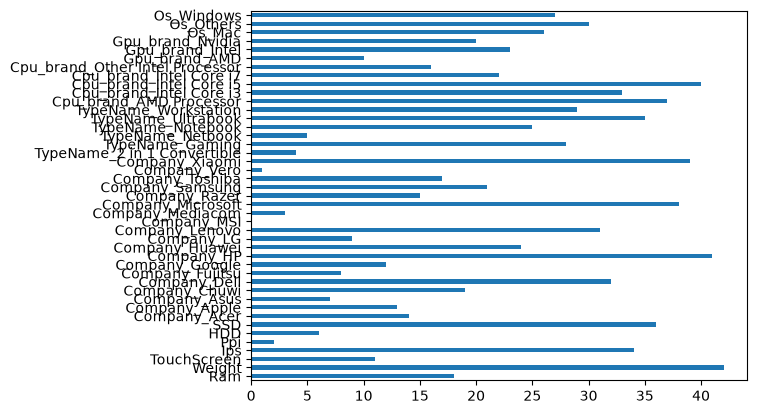

In [71]:
# Fisher score to important variables in the dataset
# pip install skfeature-chappers
from skfeature.function.similarity_based import fisher_score

# get the fisher's score rankings 
ranks = fisher_score.fisher_score(X.values, y.values)

# create a pandas DataFrame for easier interpretation
feat_importances = pd.Series(ranks, X.columns)
feat_importances.plot(kind='barh')

# how to interpret -> low score means the effect of this field is not large in the dataset
# => typically means other columns in the dataset have similar correlations/connections, 
# therefore making this particular column not so useful since other columns 
# already fill this role for this correlation

# Fisher's score studies the variance of the data -> statistical significance